# Pricing Analyst

Now use the demand estimate to infer market fundamentals.

The price coefficient is constant across brands and years, $\hat{\beta}_{price}$.

For each brand-year, compute the slope of demand with respect to price as:

$$
\hat{s}'_{bt}(p_{bt}) = \hat{\beta}_{price} s_{bt}(1 - s_{bt}).
$$

Then estimate unit cost, or marginal cost, using the firm's first-order pricing condition:

$$
\hat{c}_{bt} = p_{bt} + \frac{s_{bt}}{\hat{s}'_{bt}(p_{bt})}.
$$

Because $\hat{\beta}_{price}$ should be negative, $\hat{s}'_{bt}(p_{bt})$ should also be negative. If your price coefficient is positive, stop and debug your model before interpreting costs.

Compute:

- `demand_slope`: $\hat{s}'_{bt}(p_{bt})$
- `unit_cost`: $\hat{c}_{bt}$
- `markup`: $m_{bt} = p_{bt} - \hat{c}_{bt}$
- `average_profit`: $s_{bt} \times m_{bt}$

Here `average_profit` is a share-weighted profit index, not total dollars of profit. It is useful for comparing brand-years inside this cleaned market.


In [5]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("../data/air_fryers_clean_brand_year.csv")

# i used log_brand_share as the demand outcome
demand_model = smf.ols("""
    log_brand_share ~ avg_price
    + avg_rating
    + compact_share
    + dual_basket_share
    + oven_style_share
    + rotisserie_share
    + window_share
    + C(brand)
    + C(year)
    """,data=df).fit()

print(demand_model.summary())
price_coeff = demand_model.params["avg_price"]
print("Estimated price coefficient:", price_coeff)
print("It is negative so we can continue")
df["demand_slope"] = price_coeff * df["brand_share"] * (1 - df["brand_share"])
df["unit_cost"] = df["avg_price"] + df["brand_share"] / df["demand_slope"]
df["markup"] = df["avg_price"] - df["unit_cost"]
df["average_profit"] = df["brand_share"] * df["markup"]
df[["year","brand","avg_price","brand_share","demand_slope","unit_cost","markup", "average_profit",]].head()


                            OLS Regression Results                            
Dep. Variable:        log_brand_share   R-squared:                       0.763
Model:                            OLS   Adj. R-squared:                  0.600
Method:                 Least Squares   F-statistic:                     4.680
Date:                Mon, 04 May 2026   Prob (F-statistic):           9.24e-05
Time:                        12:24:08   Log-Likelihood:                -36.451
No. Observations:                  50   AIC:                             114.9
Df Residuals:                      29   BIC:                             155.1
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

,year,brand,avg_price,brand_share,demand_slope,unit_cost,markup,average_profit
0,2019,chefman,72.963695,0.076015,-0.002646,44.231656,28.732039,2.184062
1,2019,cosori,159.990000,0.000730,-0.000027,133.422638,26.567362,0.019385
2,2019,cuisinart,229.465274,0.107190,-0.003605,199.729962,29.735313,3.187335
3,2019,dash,55.176333,0.199721,-0.006021,22.002913,33.173420,6.625442
4,2019,gowise usa,83.575551,0.292186,-0.007790,46.068541,37.507010,10.959033



Questions:

1. What are the average unit costs and markups for each brand over the years? **Answer is in the output below**.


In [6]:
brand_summary = (
    df.groupby("brand").agg(
        avg_unit_cost=("unit_cost", "mean"),
        avg_markup=("markup", "mean"),
        avg_price=("avg_price", "mean"),
        avg_rating=("avg_rating", "mean"),
        avg_share_weighted_profit=("average_profit", "mean"),
    ).sort_values("avg_unit_cost", ascending=False)
)
brand_summary.round(3)

,avg_unit_cost,avg_markup,avg_price,avg_rating,avg_share_weighted_profit
brand,,,,,
cuisinart,194.896,29.051,223.947,4.439,2.503
oster,161.805,27.226,189.031,4.389,0.678
ninja,112.488,32.854,145.343,4.742,6.306
nuwave,109.054,27.971,137.024,4.390,1.423
cosori,86.283,27.985,114.268,4.656,1.437
instant_pot,71.903,32.558,104.461,4.559,6.010
chefman,61.569,29.369,90.938,4.428,2.821
gowise usa,56.301,31.154,87.455,4.577,4.606
ultrean,48.786,29.329,78.115,4.673,2.781


2. Are any inferred unit costs negative? If so, what might that mean?
**If negative inferred unit costs were present, it most likely is due to the demand model being misspecified, the price coefficient being too small, or market shares were measured imperfectly, etc. In this case, there are no negative inferred unit costs.** 

In [7]:
negative_costs = df[df["unit_cost"] < 0]
negative_costs[["year", "brand", "avg_price", "brand_share", "unit_cost", "markup"]]

,year,brand,avg_price,brand_share,unit_cost,markup


3. Which brands have the highest average unit costs? How do average unit cost and average ratings compare? Make scatter plots of price vs. unit cost and average rating vs. unit cost.Do more expensive products have higher consumer satisfaction?
**As we can see from the output, we see that price and unit cost have nearly perfect positive correlation, which makes sense because the inferred cost is based on price and markup. However, more expensive products do not seem to have higher consumer satisfaction, as the correlation between average rating and unit cost is negative (see output). I also found that the correlation between price and rating is negative, suggesting that more expensive air fryer brands do not seem to have higher consumer satisfaction.**

corr between price and unit cost: 0.998761547761868
corr between rating and unit cost: -0.31393271006465123
corr between price and rating: -0.29394741712305006


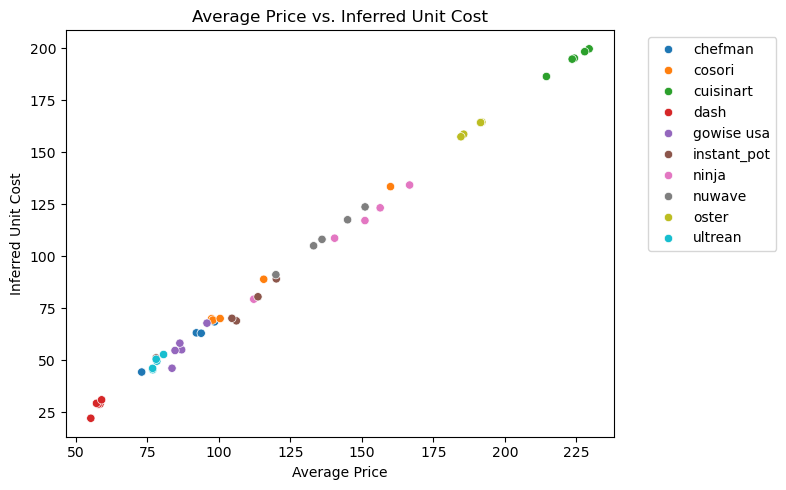

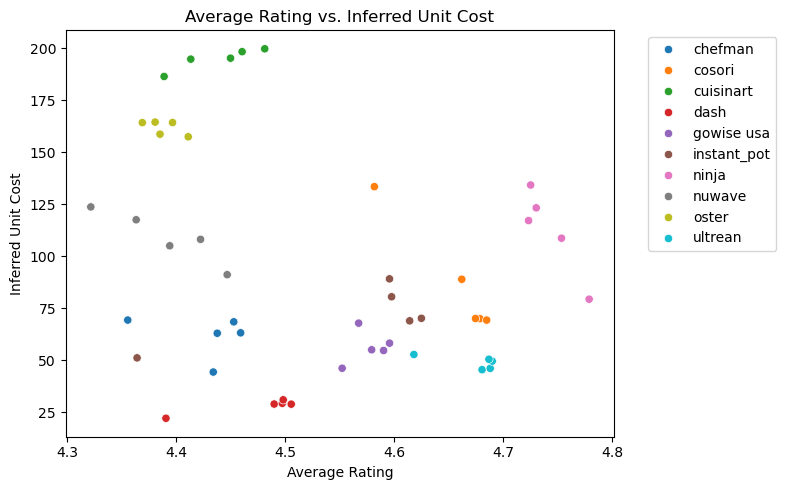

In [8]:
brand_summary.sort_values("avg_unit_cost", ascending=False).round(3)
corr_price_cost = df["avg_price"].corr(df["unit_cost"])
corr_rating_cost = df["avg_rating"].corr(df["unit_cost"])
corr_price_rating = df["avg_price"].corr(df["avg_rating"])
print("corr between price and unit cost:", corr_price_cost)
print("corr between rating and unit cost:", corr_rating_cost)
print("corr between price and rating:", corr_price_rating)

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="avg_price", y="unit_cost", hue="brand")
plt.title("Average Price vs. Inferred Unit Cost")
plt.xlabel("Average Price")
plt.ylabel("Inferred Unit Cost")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="avg_rating", y="unit_cost", hue="brand")
plt.title("Average Rating vs. Inferred Unit Cost")
plt.xlabel("Average Rating")
plt.ylabel("Inferred Unit Cost")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

4. Make kernel density plots of unit costs, markups, and average profit, in general and hued by brand.


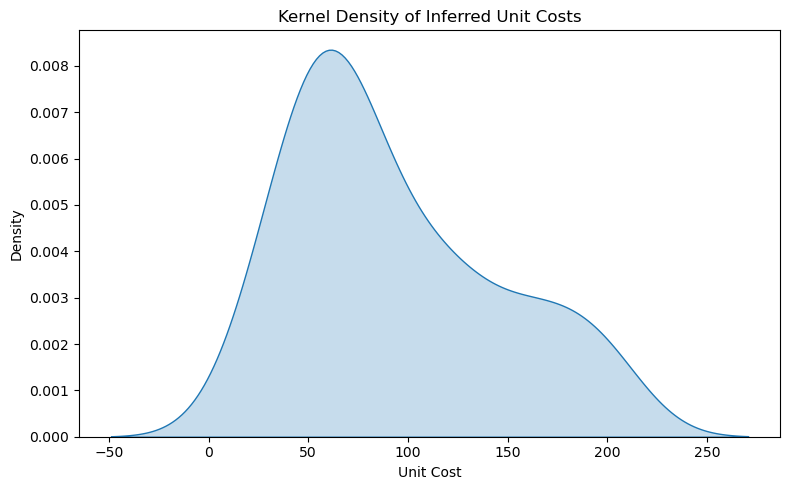

In [9]:
plt.figure(figsize=(8, 5))
sns.kdeplot(data=df, x="unit_cost", fill=True)
plt.title("Kernel Density of Inferred Unit Costs")
plt.xlabel("Unit Cost")
plt.tight_layout()
plt.show()

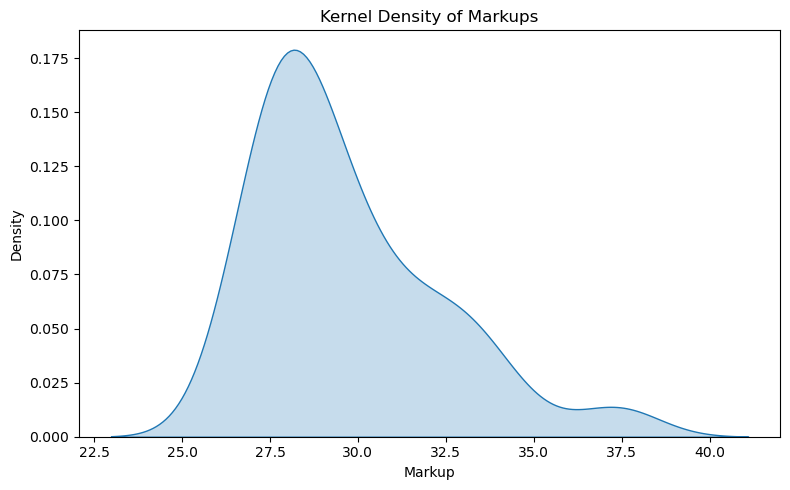

In [10]:
plt.figure(figsize=(8, 5))
sns.kdeplot(data=df, x="markup", fill=True)
plt.title("Kernel Density of Markups")
plt.xlabel("Markup")
plt.tight_layout()
plt.show()

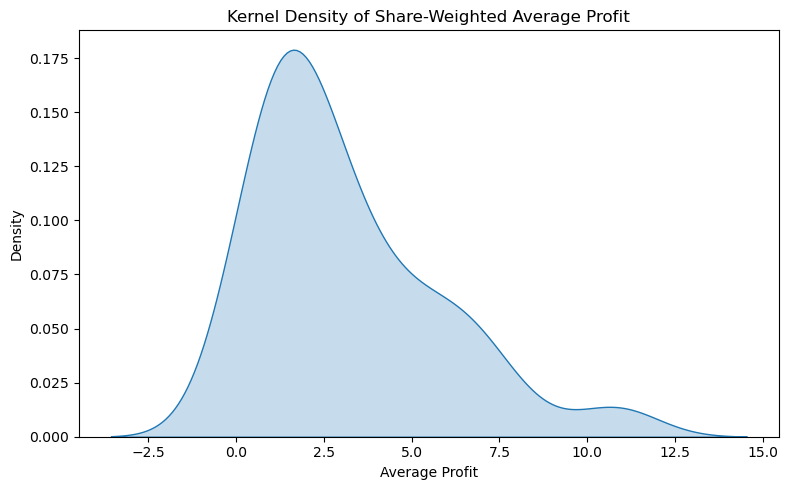

In [11]:
plt.figure(figsize=(8, 5))
sns.kdeplot(data=df, x="average_profit", fill=True)
plt.title("Kernel Density of Share-Weighted Average Profit")
plt.xlabel("Average Profit")
plt.tight_layout()
plt.show()

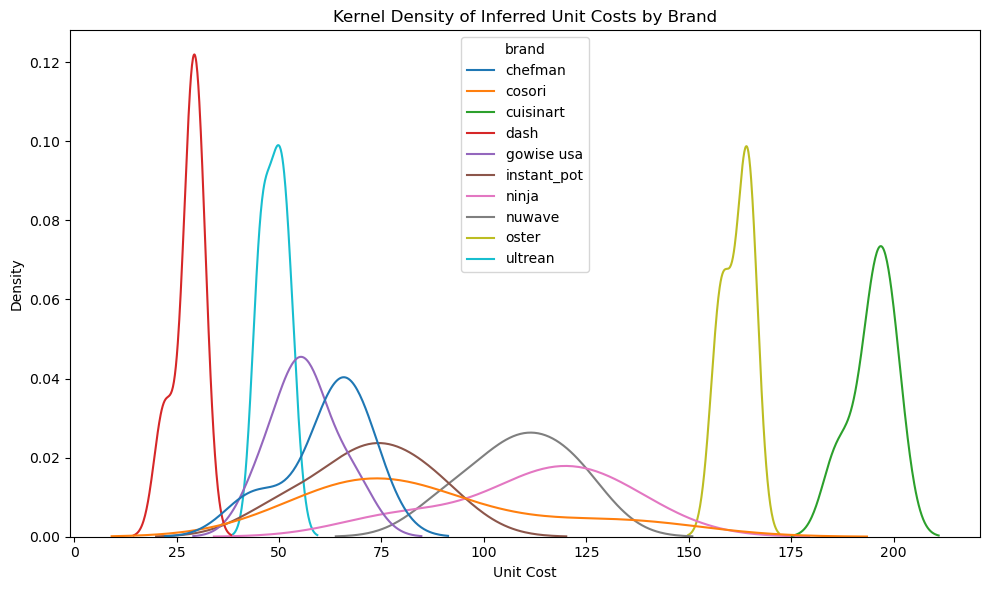

In [12]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x="unit_cost", hue="brand", common_norm=False)
plt.title("Kernel Density of Inferred Unit Costs by Brand")
plt.xlabel("Unit Cost")
plt.tight_layout()
plt.show()

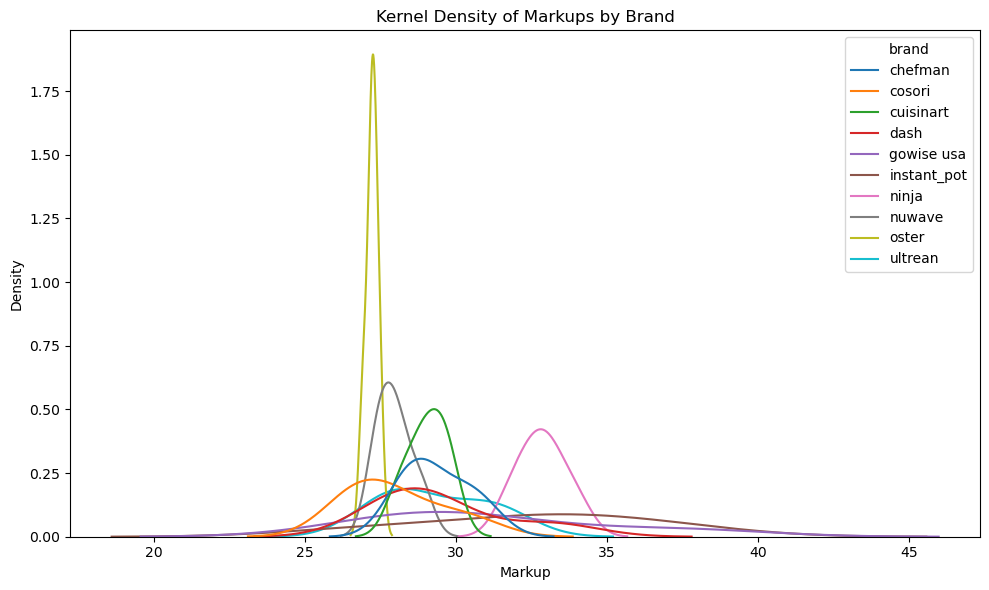

In [13]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x="markup", hue="brand", common_norm=False)
plt.title("Kernel Density of Markups by Brand")
plt.xlabel("Markup")
plt.tight_layout()
plt.show()

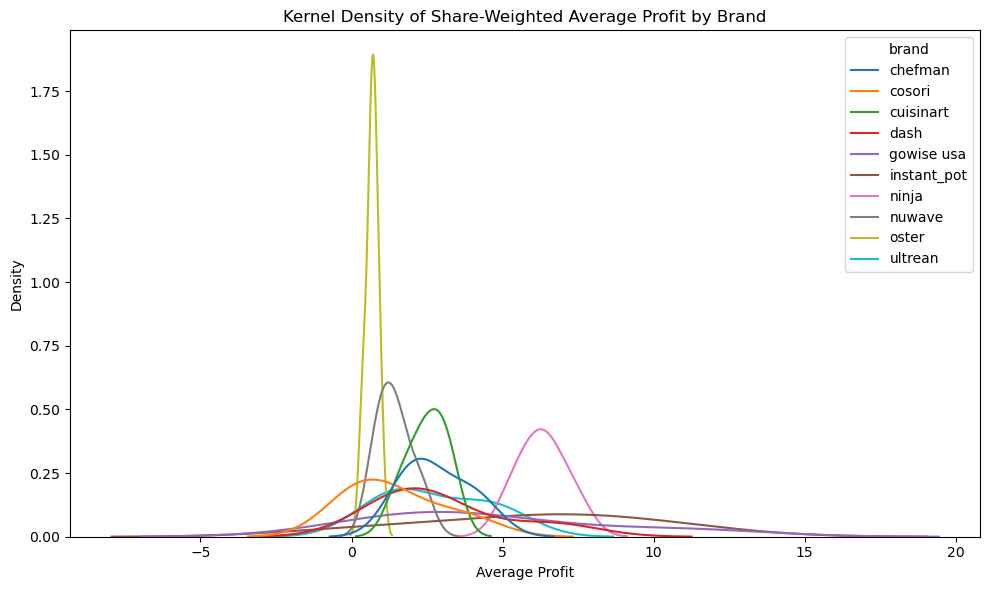

In [14]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x="average_profit", hue="brand", common_norm=False)
plt.title("Kernel Density of Share-Weighted Average Profit by Brand")
plt.xlabel("Average Profit")
plt.tight_layout()
plt.show()

5. Which brands have the highest share-weighted average profit?
**Based on the output below, the brands with the highest share-weighted average profit are `ninja`, `instant_pot`, `gowise usa`, `dash`, and `chefman`.


In [15]:
profit_ranking = brand_summary.sort_values("avg_share_weighted_profit",ascending=False)
profit_ranking[["avg_share_weighted_profit", "avg_markup", "avg_unit_cost", "avg_rating"]].round(3)

,avg_share_weighted_profit,avg_markup,avg_unit_cost,avg_rating
brand,,,,
ninja,6.306,32.854,112.488,4.742
instant_pot,6.010,32.558,71.903,4.559
gowise usa,4.606,31.154,56.301,4.577
dash,2.994,29.542,27.937,4.476
chefman,2.821,29.369,61.569,4.428
ultrean,2.781,29.329,48.786,4.673
cuisinart,2.503,29.051,194.896,4.439
cosori,1.437,27.985,86.283,4.656
nuwave,1.423,27.971,109.054,4.390



This part of the work is the **pricing analyst** or **applied economist** role: using a demand model to reason about price, cost, and profitability. This kind of analysis could be used to think about investing in this market, or how to adjust a product line to be more competitive.